In [1]:
import pandas as pd
import numpy as np

In [2]:
pip install regex

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import re

In [4]:
df = pd.read_csv("D:/01 Data Analytics Projects/Project 2/dataset/Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.SeniorCitizen.unique

<bound method Series.unique of 0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, Length: 7043, dtype: int64>

In [7]:
df.shape

(7043, 21)

In [8]:
df.columns = df.columns.str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True) 

In [9]:
#as there are 21 rows and to make coding easier we have to make columns lowercase
df.columns = df.columns.str.lower()

In [10]:
df.columns = df.columns.str.replace(" ","_")

In [11]:
df.columns

Index(['customer_i_d', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_t_v', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='str')

In [12]:
df.rename(columns={'customer_i_d' : 'customer_id', 'streaming_t_v' : 'streaming_tv'}, inplace=True)

In [13]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='str')

In [14]:
df['total_charges']


0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: total_charges, Length: 7043, dtype: str

In [15]:
df.info

<bound method DataFrame.info of      customer_id  gender  senior_citizen partner dependents  tenure  \
0     7590-VHVEG  Female               0     Yes         No       1   
1     5575-GNVDE    Male               0      No         No      34   
2     3668-QPYBK    Male               0      No         No       2   
3     7795-CFOCW    Male               0      No         No      45   
4     9237-HQITU  Female               0      No         No       2   
...          ...     ...             ...     ...        ...     ...   
7038  6840-RESVB    Male               0     Yes        Yes      24   
7039  2234-XADUH  Female               0     Yes        Yes      72   
7040  4801-JZAZL  Female               0     Yes        Yes      11   
7041  8361-LTMKD    Male               1     Yes         No       4   
7042  3186-AJIEK    Male               0      No         No      66   

     phone_service    multiple_lines internet_service online_security  ...  \
0               No  No phone service 

In [16]:
df.drop('customer_id', axis=1, inplace=True)

In [17]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='str')

In [18]:
df.isnull().sum()

gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [19]:
df['total_charges'].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [20]:
(df['total_charges'] == ' ').sum()

np.int64(11)

In [21]:
df['total_charges'].dtype

<StringDtype(storage='python', na_value=nan)>

In [22]:
df['total_charges'] = df['total_charges'].replace('',np.nan)

In [23]:
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

In [24]:
df.isnull().sum()

gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

In [25]:
(df=='').sum()

gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [26]:
df.isnull().sum() + (df=='').sum()

gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

In [27]:
df=df.replace('',np.nan)

In [28]:
df.isnull().sum()

gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

In [29]:
df.dropna(inplace=True)

In [30]:
df.isnull().sum()

gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [31]:
df.select_dtypes(include='object').columns

C:\Users\HP\AppData\Local\Temp\ipykernel_9768\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'churn'],
      dtype='str')

In [32]:
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
df['churn'].unique()
df['churn'].value_counts()

churn
No     5163
Yes    1869
Name: count, dtype: int64

In [34]:
#Encoding columns ; first normalizing column with more than 2 values
service_cols = [
    'multiple_lines', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies'
]
for col in service_cols:
    df[col] = df[col].replace({
        'No internet service' : 'No',
        'No phone service' : 'No'    
    })

In [35]:
#no converting every column in binary form 
binary_cols = [
    'partner', 'dependents', 'phone_service', 'multiple_lines',
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies',
    'paperless_billing', 'churn'
]
for col in binary_cols:
    df[col]=df[col].map({'Yes':1, 'No':0})

In [36]:
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [37]:
df=pd.get_dummies(df,columns=['gender','internet_service','contract','payment_method'],drop_first = True)

In [38]:
df.info

<bound method DataFrame.info of       senior_citizen  partner  dependents  tenure  phone_service  \
0                  0        1           0       1              0   
1                  0        0           0      34              1   
2                  0        0           0       2              1   
3                  0        0           0      45              0   
4                  0        0           0       2              1   
...              ...      ...         ...     ...            ...   
7038               0        1           1      24              1   
7039               0        1           1      72              1   
7040               0        1           1      11              0   
7041               1        1           0       4              1   
7042               0        0           0      66              1   

      multiple_lines  online_security  online_backup  device_protection  \
0                  0                0              1                  0   
1

In [39]:
df.head()

,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,...,total_charges,churn,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,29.85,0,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,1889.50,0,True,False,False,True,False,False,False,True
2,0,0,0,2,1,0,1,1,0,0,...,108.15,1,True,False,False,False,False,False,False,True
3,0,0,0,45,0,0,1,0,1,1,...,1840.75,0,True,False,False,True,False,False,False,False
4,0,0,0,2,1,0,0,0,0,0,...,151.65,1,False,True,False,False,False,False,True,False


In [40]:
df.columns

Index(['senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service',
       'multiple_lines', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'paperless_billing', 'monthly_charges', 'total_charges', 'churn',
       'gender_Male', 'internet_service_Fiber optic', 'internet_service_No',
       'contract_One year', 'contract_Two year',
       'payment_method_Credit card (automatic)',
       'payment_method_Electronic check', 'payment_method_Mailed check'],
      dtype='str')

In [41]:
df.head()

,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,...,total_charges,churn,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,29.85,0,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,1889.50,0,True,False,False,True,False,False,False,True
2,0,0,0,2,1,0,1,1,0,0,...,108.15,1,True,False,False,False,False,False,False,True
3,0,0,0,45,0,0,1,0,1,1,...,1840.75,0,True,False,False,True,False,False,False,False
4,0,0,0,2,1,0,0,0,0,0,...,151.65,1,False,True,False,False,False,False,True,False


In [42]:
df['churn'].value_counts(normalize=True)

churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [43]:
df.groupby('churn')[['tenure','monthly_charges','total_charges']].mean()

,tenure,monthly_charges,total_charges
churn,,,
0,37.650010,61.307408,2555.344141
1,17.979133,74.441332,1531.796094


In [44]:
## Categorical Analysis (Most IMP)
pd.crosstab(df['contract_One year'],df['churn'],normalize='index')

churn,0,1
contract_One year,,
False,0.693705,0.306295
True,0.887228,0.112772


In [45]:
pd.crosstab(df['contract_Two year'],df['churn'],normalize='index')

churn,0,1
contract_Two year,,
False,0.659435,0.340565
True,0.971513,0.028487


In [46]:
pd.crosstab(df['internet_service_Fiber optic'], df['churn'], normalize='index')

churn,0,1
internet_service_Fiber optic,,
False,0.854675,0.145325
True,0.581072,0.418928


In [47]:
pd.crosstab(df['payment_method_Electronic check'], df['churn'], normalize='index')

churn,0,1
payment_method_Electronic check,,
False,0.829012,0.170988
True,0.547146,0.452854


In [48]:
pd.crosstab(df['tech_support'], df['churn'], normalize='index')

churn,0,1
tech_support,,
0,0.687700,0.312300
1,0.848039,0.151961


In [49]:
##Visualization
import matplotlib.pyplot as plt
import seaborn as sns

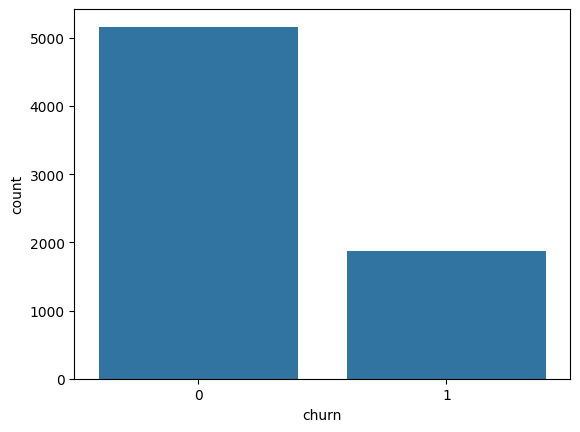

In [50]:
sns.countplot(x='churn', data=df)
plt.show()

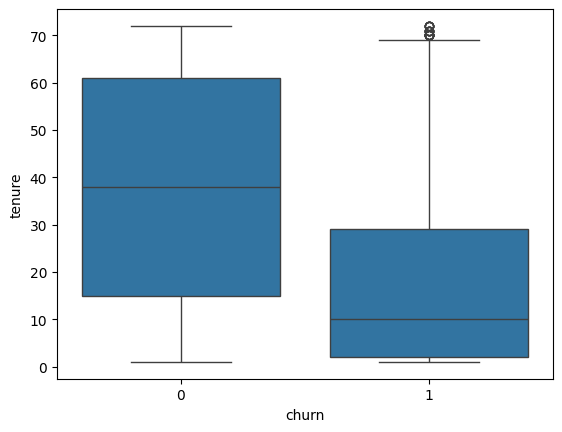

In [51]:
sns.boxplot(x='churn', y='tenure', data=df)
plt.show()

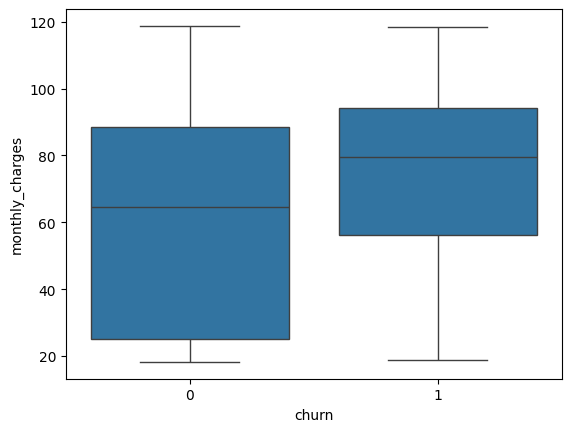

In [52]:
sns.boxplot(x='churn', y='monthly_charges', data=df)
plt.show()

In [53]:
df.head()

,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,...,total_charges,churn,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,29.85,0,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,1889.50,0,True,False,False,True,False,False,False,True
2,0,0,0,2,1,0,1,1,0,0,...,108.15,1,True,False,False,False,False,False,False,True
3,0,0,0,45,0,0,1,0,1,1,...,1840.75,0,True,False,False,True,False,False,False,False
4,0,0,0,2,1,0,0,0,0,0,...,151.65,1,False,True,False,False,False,False,True,False


In [55]:
df.to_csv("churned_cleaned_csv", index=False)